“Given a location, what combination of features maximizes consistent demand (and reasonable price)?”

### Feature Encoding

Categorical variables were converted into numerical format in the data wrangling stage. This includes:

- Room type variables encoded using one-hot encoding (e.g., hotel room, private room, shared room)
- Amenities transformed into binary indicator variables (e.g., amenity_wifi, amenity_pool)

As a result, all features used in the modeling stage are already in a machine-readable numeric format, and no additional encoding was required in this step.

### Modeling Strategy

<b>Step 1: Build interpretable baseline linear model</b>
   * Linear Regression
   * Establish baseline performance
   * Understand directional relationships
   * Interpret coefficients


<b>Step 2: Address multicollinearity / overfitting</b>
   * Ridge / Lasso Regression
   * Improve generalization of linear model
   * Reduce impact of correlated features
   * Perform feature shrinkage/selection


<b>Step 3: Compare against nonlinear ensemble model</b> 
   * Random Forest Regressor
   * Capture nonlinear relationships
   * Capture feature interactions automatically
   * Estimate relative feature importance


<b>Step 4: Test advanced boosting model </b> 
   * XGBoost / Gradient Boosting
   * Optimize predictive performance
   * Compare against Random Forest benchmark
   * Assess marginal gains vs complexity

<b>Step 5: Evaluate tradeoffs</b>
   * Compare all model metrics
   * Balance interpretability vs predictive power
   * Select final recommended model

### Questions to answer: 
Linear Models Will Help Answer:
* How much does an amenity independently impact nightly price?
* How much additional price is associated with each bedroom/bathroom?
* Is superhost status predictive when other listing characteristics are controlled?

Tree Models Will Help Answer:
* Are there nonlinear pricing thresholds? (do prices skyrocket or plateau at a certain point?)
* Do amenities interact to create compounded pricing effects? 
* Which features are most influential overall in price prediction?

General notes / Questions (not for capstone):
Apriori / FP-Growth for amenities
Amenity bundling insights
Market segmentation
Design/package recommendations

Genetic Algorithms
Airbnb Optimization

Find best amenity package:

Given budget $15k, which upgrades maximize ADR
Optimize renovation package combinations:

Which improvements maximize ROI under budget?

Notes: In the above example of real estate price estimation, it seems difficult to predict the exact price of a real estate. However, if we reformulate the problem as predicting the price range of real estate instead of a single price tag, then we could expect to obtain a more robust model. As a result, we transform the problem into a classification problem, instead of regression.

most helpful analogy: The more stable the performance of a learner, the less its variance. In the game of dart, a learner with high variance corresponds to a lousy player who rarely lands the dart in the same place. On the other hand, a learner with low variance could correspond to a decent player who rarely misses the bullseye.



### THINGS TO TRY
* Let's test different models
* hyperparameter tuning
* model performance evaluation
* using pipelines
* We can easily compute the relative frequencies (percentages) to better quantify differences in the incidences of the classes: class_percentages = pd.Series([(x / dflog.shape[0]) * 100.00 for x in class_counts])
class_percentages (but using applicable code/df)
* Now we can use the percentages as labels and plot the distribution of the two classes:
* 

There are two important challenges posed by ICPs:

The difference in the size of the classes is inherent to the problem under study. This means that one cannot pave this difference by adding more elements to the minority class.

Classification algorithms are usually negatively affected by the lack of sufficient samples of the minority class, in that the models built with them are practically unable to differentiate the minority class from the majority class, where the former is the one of interest. For instance, imagine a model built to compute the likelihod of a patient developing Cancer that nearly always predicts a small likelihood for this class (meaning, that the model predicts NO Cancer, when it should have predicted Cancer in some cases).

Do we need to run a confusion matrix for this? 


## Imports 

In [91]:
!pip install xgboost

In [92]:
# Core tools
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Train/test split
from sklearn.model_selection import train_test_split, cross_val_score

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Load Clean Data

In [13]:
df = pd.read_csv('../data/processed/airbnb_eda_clean.csv')

## Inspect Dataset

In [16]:
df.head()

,id,host_id,room_type_hotel_room,room_type_private_room,room_type_shared_room,accommodates,bedrooms,beds,bathrooms,host_is_superhost,...,amenity_workspace,city,price_log,number_of_reviews_log,beds_log,accommodates_log,bedrooms_log,bathrooms_log,room_type,rating_bin
0,108061,320564,0,0,0,2,1.0,1.0,1.0,1.0,...,0,Asheville,4.615121,4.532599,0.693147,1.098612,0.693147,0.693147,Entire home/apt,"(-0.001, 80.0]"
1,155305,746673,0,0,0,2,1.0,1.0,1.0,0.0,...,0,Asheville,4.615121,5.950643,0.693147,1.098612,0.693147,0.693147,Entire home/apt,"(-0.001, 80.0]"
2,156805,746673,0,1,0,2,1.0,1.0,2.5,0.0,...,0,Asheville,4.204693,4.219508,0.693147,1.098612,0.693147,1.252763,Private room,"(-0.001, 80.0]"
3,197263,961396,0,1,0,2,1.0,1.0,1.0,1.0,...,1,Asheville,3.828641,4.204693,0.693147,1.098612,0.693147,0.693147,Private room,"(-0.001, 80.0]"
4,209068,1029919,0,0,0,4,1.0,2.0,1.0,1.0,...,1,Asheville,4.615121,4.110874,1.098612,1.609438,0.693147,0.693147,Entire home/apt,"(-0.001, 80.0]"


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266350 entries, 0 to 266349
Data columns (total 83 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   id                             266350 non-null  int64  
 1   host_id                        266350 non-null  int64  
 2   room_type_hotel_room           266350 non-null  int64  
 3   room_type_private_room         266350 non-null  int64  
 4   room_type_shared_room          266350 non-null  int64  
 5   accommodates                   266350 non-null  int64  
 6   bedrooms                       266350 non-null  float64
 7   beds                           266350 non-null  float64
 8   bathrooms                      266350 non-null  float64
 9   host_is_superhost              266350 non-null  float64
 10  host_response_time_ord         266350 non-null  float64
 11  price                          266350 non-null  float64
 12  latitude                      

In [15]:
df.shape

(266350, 83)

## Define Target

In [70]:
#y = df['reviews_per_month']

# Update target to demand (log-transformed reviews per month)
y = np.log1p(df['reviews_per_month'])

In [68]:
y.describe()

count    266350.000000
mean          0.620950
std           0.598457
min           0.000000
25%           0.048790
50%           0.457425
75%           1.085189
max           4.629082
Name: reviews_per_month, dtype: float64

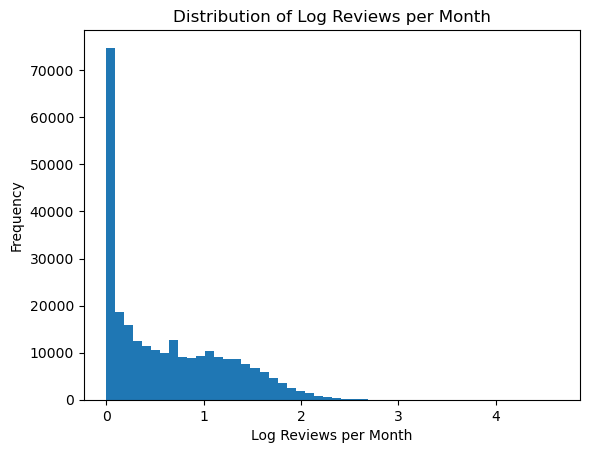

In [72]:
plt.hist(y, bins=50)
plt.title("Distribution of Log Reviews per Month")
plt.xlabel("Log Reviews per Month")
plt.ylabel("Frequency")
plt.show()

# clearly skewed - could run another model on active listings with reviews > 0, but will leave as is for now. 

## Baseline Model
### select features, split, model, fit, predict

In [30]:
# Select core listing features (baseline model)
features = [
    'accommodates',
    'bedrooms',
    'beds',
    'bathrooms',
    'latitude',
    'longitude',
    'host_is_superhost',
    'instant_bookable',
    'review_scores_rating']

X = df[features]

In [31]:
# Split data into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [73]:
# Create baseline linear regression model
baseline_model = LinearRegression()
baseline_model.fit(X_train, y_train)

LinearRegression()

In [74]:
# Extract baseline model coefficients
coefficients = pd.DataFrame({
    'feature': X.columns,
    'coefficient': baseline_model.coef_
})

coefficients.sort_values(by='coefficient', ascending=False).reset_index(drop=True)

,feature,coefficient
0,accommodates,0.135389
1,bathrooms,0.117772
2,bedrooms,0.064746
3,instant_bookable,0.039127
4,host_is_superhost,0.024336
5,longitude,-0.002100
6,latitude,-0.020422
7,beds,-0.027852
8,review_scores_rating,-0.035795


In [75]:
y_pred = baseline_model.predict(X_test)

In [76]:
# Evaluate model performance using MAE and R²
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("R2:", r2)

MAE: 0.46440108779748696
R2: 0.4477536507210431


## Interpretation:
* Baseline model explains around 45% of price variation.
* Core drivers like size, location, and host features have meaningful predictive power.
* Next step: assess whether amenities improve model performance.

## Handle Amenities

In [36]:
# Identify amenity columns
amenity_cols = [col for col in df.columns if col.startswith('amenity_')]

len(amenity_cols)

56

In [ ]:
# Check most common amenities
amenity_frequency = df[amenity_cols].mean().sort_values(ascending=False)

amenity_frequency.head(20)

In [45]:
# Keep amenities between 5% and 95% frequency
selected_amenities = amenity_frequency[
    (amenity_frequency > 0.05) & (amenity_frequency < 0.95)
].index.tolist()

len(selected_amenities)

48

In [47]:
rare_amenities = amenity_frequency[(amenity_frequency < 0.05)].index.tolist()

rare_amenities

['amenity_view_nature',
 'amenity_view_water',
 'amenity_view_other',
 'amenity_ev_charger',
 'amenity_musical_instruments',
 'amenity_game_console',
 'amenity_ski_access']

### Analysis: 
I'm curious to see if these rare amenities are more common in specific cities, and if so, what the effect is on price/booking. I may look into this later. 

In [48]:
# Add selected amenities to feature set
features_with_amenities = features + selected_amenities
X2 = df[features_with_amenities]


In [77]:
# Use same train/test split as baseline model
X2_train = X2.loc[X_train.index]
X2_test = X2.loc[X_test.index]

In [78]:
# train model
model2 = LinearRegression()
model2.fit(X2_train, y_train)

LinearRegression()

In [79]:
# predict
y_pred2 = model2.predict(X2_test)

In [80]:
# evaluate
mae2 = mean_absolute_error(y_test, y_pred2)
r2_2 = r2_score(y_test, y_pred2)

print("With Amenities MAE:", mae2)
print("With Amenities R2:", r2_2)

With Amenities MAE: 0.4258827880067409
With Amenities R2: 0.5222564162033898


In [53]:
print("Baseline MAE:", mae)
print("With Amenities MAE:", mae2)

print("Baseline R2:", r2)
print("With Amenities R2:", r2_2)

Baseline MAE: 0.46440108779748696
With Amenities MAE: 0.4258827880067409
Baseline R2: 0.4477536507210431
With Amenities R2: 0.5222564162033898


## Analysis:
* Core features like location, bedrooms, and bathrooms explain most of the pricing
* Amenities did improve the model performance and explained variance.

## Ridge Regression

In [94]:
scaler = StandardScaler()

X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled = scaler.transform(X2_test)

In [95]:
# Ridge Regression

ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X2_train, y_train)

y_pred_ridge = ridge.predict(X2_test)

mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print("Ridge MAE:", mae_ridge)
print("Ridge R2:", r2_ridge)


Ridge MAE: 0.42588280361187486
Ridge R2: 0.5222563405312144


## Lasso Regression

In [96]:
# Lasso Regression

lasso = Lasso(alpha=0.001, random_state=42, max_iter=10000)
lasso.fit(X2_train, y_train)

y_pred_lasso = lasso.predict(X2_test)

mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
r2_lasso = r2_score(y_test, y_pred_lasso)

print("Lasso MAE:", mae_lasso)
print("Lasso R2:", r2_lasso)

Lasso MAE: 0.42615187029128637
Lasso R2: 0.5214098869348306


## Compare Models

In [97]:
## Compare Models

print("\n--- Model Comparison ---")
print("Baseline R2:", r2)
print("With Amenities R2:", r2_2)
print("Ridge R2:", r2_ridge)
print("Lasso R2:", r2_lasso)


--- Model Comparison ---
Baseline R2: 0.4477536507210431
With Amenities R2: 0.5222564162033898
Ridge R2: 0.5222563405312144
Lasso R2: 0.5214098869348306


In [98]:
# --- Lasso Feature Selection (non-zero coefficients) ---
lasso_coeffs = pd.DataFrame({
    'feature': X2.columns,
    'coefficient': lasso.coef_
})

selected_features_lasso = lasso_coeffs[lasso_coeffs['coefficient'] != 0]

selected_features_lasso.sort_values(by='coefficient', ascending=False).head()

,feature,coefficient
53,amenity_beach_access,0.246870
11,amenity_tv,0.203648
47,amenity_gym,0.131130
36,amenity_dishwasher,0.118315
0,accommodates,0.112322


## Random Forest

In [87]:
# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X2_train, y_train)

y_pred_rf = rf.predict(X2_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest R2:", r2_rf)

Random Forest MAE: 0.28293130059753174
Random Forest R2: 0.7556727919518577


In [88]:
rf_importance = pd.DataFrame({
    'feature': X2.columns,
    'importance': rf.feature_importances_
})

rf_importance.sort_values(by='importance', ascending=False).head(15)

,feature,importance
0,accommodates,0.347311
3,bathrooms,0.141485
5,longitude,0.134679
4,latitude,0.090033
8,review_scores_rating,0.031397
1,bedrooms,0.021098
47,amenity_gym,0.017244
2,beds,0.010685
23,amenity_parking_free,0.010152
45,amenity_pool,0.007847


## Interpretation:
* Random Forest MAE: 0.28 is a much lower score for error
* Random Forest R2: 0.76 has a much stronger prediction score
* Linear models were underfitting

### Feature Importance / Main Drivers
* accommodates (0.35) → biggest factor
* bathrooms (0.14)
* longitude / latitude

### Feature Importance / Secondary Drivers
* review_scores_rating
* bedrooms

### Amenity Drivers
* gym, parking, pool, hot tub, private entrance, kitchen, beach access

### Summary:
Demand is mostly driven by listing capacity and location, as well as quality (review scores), while certain amenities added perceived value.

## XG Boost

In [93]:
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X2_train, y_train)

y_pred_xgb = xgb.predict(X2_test)

print("XGBoost R2:", r2_score(y_test, y_pred_xgb))

XGBoost R2: 0.733014129847044


## Overview

In [ ]:
#Logistic regression

from sklearn.linear_model import LogisticRegression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
logreg = LogisticRegression()
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)
 Voting Ensemble for Classification 

from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier 
from sklearn.svm import SVC 
from sklearn.ensemble import VotingClassifier 
kfold = model_selection.KFold(n_splits=10, random_state=seed) 
# create the sub models
estimators = [] 
model1 = LogisticRegression() 
estimators.append(('logistic', model1)) 
model2 = DecisionTreeClassifier() 
estimators.append(('cart', model2)) 
model3 = SVC()
estimators.append(('svm', model3)) 
# create the ensemble model 
ensemble=VotingClassifier(estimators) 
results = model_selection.cross_val_score(ensemble, X, Y, cv=kfold)
print(results.mean())


## Rare Amenity Analysis (Exploratory)


In [ ]:
df.groupby('city')['amenity_ski_access'].mean()

In [ ]:
df.groupby('amenity_ski_access')['price'].mean()

In [ ]:
df.groupby('amenity_ski_access')['reviews_per_month'].mean()